In [274]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [275]:
df=pd.read_csv("HR_Analytics.csv")

In [276]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   str    
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   str    
 3   Attrition                 1480 non-null   str    
 4   BusinessTravel            1480 non-null   str    
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   str    
 7   DistanceFromHome(KM)      1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   str    
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   str    
 14  JobInvolvement     

In [277]:
df.isna().sum()

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome(KM)         0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
HourlyRate                   0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
SalaryHike %                 0
PerformanceRating            0
RelationshipSatisfaction     0
StandardWorkingHours         0
StockOptionLevel             0
TotalExperience(Years)       0
TrainingsLastYear            0
WorkLife

In [278]:
df.shape

(1480, 37)

In [279]:
df.size

54760

In [280]:
df.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome(KM)', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'SalarySlab', 'HourlyRate',
       'NumCompaniesWorked', 'Over18', 'OverTime', 'SalaryHike %',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardWorkingHours',
       'StockOptionLevel', 'TotalExperience(Years)', 'TrainingsLastYear',
       'WorkLifeBalance', 'YearsatCompany', 'YearsinCurrentRole',
       'YearsSincePromotion', 'YearsWithCurrManager'],
      dtype='str')

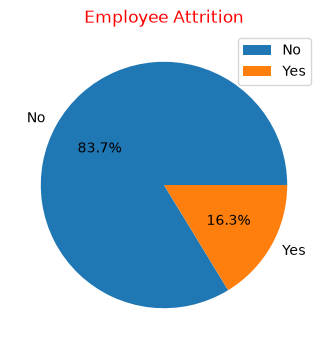

In [281]:
plt.figure(figsize=(4,4))
plt.pie(df['Attrition'].value_counts(),labels=df['Attrition'].value_counts().index,autopct='%1.1f%%')
plt.title('Employee Attrition',color='red')
plt.legend()
plt.show()

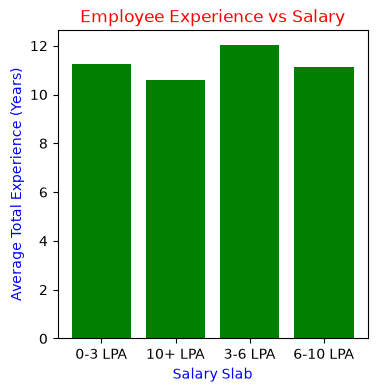

In [282]:
plt.figure(figsize=(4,4))
salary_vs_experience = df.groupby('SalarySlab')['TotalExperience(Years)'].mean().sort_index()
plt.bar(salary_vs_experience.index,salary_vs_experience.values,color='green')
plt.xlabel('Salary Slab',color='blue')
plt.ylabel('Average Total Experience (Years)',color='blue')
plt.title('Employee Experience vs Salary',color='red')
plt.show()

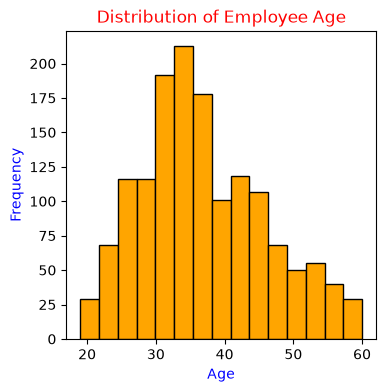

In [283]:
plt.figure(figsize=(4,4))
plt.hist(df['Age'],bins=15,color='orange',edgecolor='black')
plt.xlabel('Age',color='blue')
plt.ylabel('Frequency',color='blue')
plt.title('Distribution of Employee Age',color='red')
plt.show()

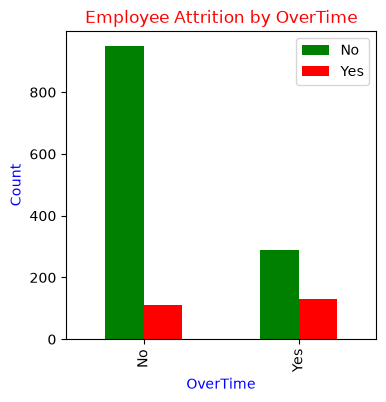

In [284]:
pd.crosstab(df['OverTime'],df['Attrition']).plot(kind='bar',figsize=(4,4),color=['green','red'])
plt.xlabel('OverTime',color='blue')
plt.ylabel('Count',color='blue')
plt.title('Employee Attrition by OverTime',color='red')
plt.legend()
plt.show()

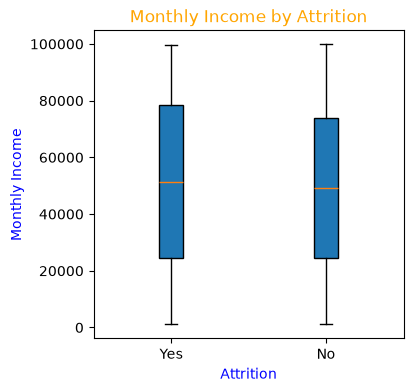

In [285]:
plt.figure(figsize=(4,4))
data = [df[df['Attrition'] == 'Yes']['MonthlyIncome'],df[df['Attrition'] == 'No']['MonthlyIncome']]
plt.boxplot(data, patch_artist=True)
plt.xticks([1, 2], ['Yes', 'No'])
plt.title('Monthly Income by Attrition', color='orange')
plt.xlabel('Attrition', color='blue')
plt.ylabel('Monthly Income', color='blue')
plt.show()

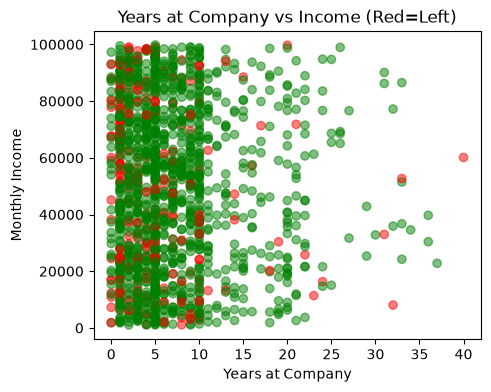

In [286]:
plt.figure(figsize=(5,4))
plt.scatter(df['YearsatCompany'], df['MonthlyIncome'], c=df['Attrition'].map({'Yes':'red','No':'green'}), alpha=0.5)
plt.title("Years at Company vs Income (Red=Left)")
plt.xlabel("Years at Company")
plt.ylabel("Monthly Income")
plt.show()

In [287]:
# Label Encoder

from sklearn.preprocessing import LabelEncoder
df_label = df.copy()
le = LabelEncoder()
label_columns = ['Attrition', 'Gender', 'Department', 'JobRole', 'EducationField', 'MaritalStatus', 'OverTime']
for col in label_columns:
    df_label[col] = le.fit_transform(df_label[col])
    print(f"{col} : {list(le.classes_)} -> {list(range(len(le.classes_)))}")
print(df_label[label_columns].head())



Attrition : ['No', 'Yes'] -> [0, 1]
Gender : ['Female', 'Male'] -> [0, 1]
Department : ['Administration', 'Finance', 'Human Resources', 'IT', 'Marketing', 'Operations', 'Sales'] -> [0, 1, 2, 3, 4, 5, 6]
JobRole : ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative'] -> [0, 1, 2, 3, 4, 5, 6, 7, 8]
EducationField : ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree'] -> [0, 1, 2, 3, 4, 5]
MaritalStatus : ['Married', 'Single'] -> [0, 1]
OverTime : ['No', 'Yes'] -> [0, 1]
   Attrition  Gender  Department  JobRole  EducationField  MaritalStatus  \
0          1       1           0        2               1              1   
1          0       0           6        8               3              1   
2          1       1           6        8               2              1   
3          0       1           0        6  

In [288]:
# Ordinal Encoder

from sklearn.preprocessing import OrdinalEncoder
df_ordinal = df.copy()
ordinal_columns = ['AgeGroup', 'BusinessTravel', 'SalarySlab']
ord_encoder = OrdinalEncoder() 
df_ordinal[ordinal_columns] = ord_encoder.fit_transform(df_ordinal[ordinal_columns])
print(ord_encoder.categories_) 

[array(['18-25', '26-35', '36-45', '46-55', '55+'], dtype=object), array(['Non-Travel', 'Travel-Frequently', 'TravelRarely', 'Travel_Rarely'],
      dtype=object), array(['0-3 LPA', '10+ LPA', '3-6 LPA', '6-10 LPA'], dtype=object)]
